# Question 1 — borough clustering, trajectories and uncertainty

This notebook asks two connected questions. First, do boroughs form a reproducible **structural typology** based on their complete eight-year activity and local context? Second, do boroughs share similar **activity trajectories**, either in their absolute level or only in the shape of change?

Clustering is exploratory and has no true target label. All eight years are used in the main analysis so the typology reflects the complete observed period. Candidate solutions are judged by separation, resampling stability, minimum cluster size and borough-level assignment uncertainty. Figures are displayed without saving additional files.

## 1. Data and common rules

The analysis uses the 32 boroughs observed in all eight annual waves. Candidate solutions compare K-means and Ward clustering for 2–8 groups. Solutions containing fewer than three boroughs are excluded, while the effect of using a minimum of four is checked explicitly.

Candidate stability uses 500 resamples; selected solutions then use 1,000 resamples to estimate borough-level membership probabilities. A label accompanied by low probability is treated as borderline rather than as a fixed borough type.


In [1]:
# Load the annual borough panel, map boundaries and clustering libraries.
from pathlib import Path
import os
import warnings

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Load the libraries required for this section.
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
# Load the libraries required for this section.
from sklearn.metrics import (
    adjusted_rand_score, calinski_harabasz_score,
    davies_bouldin_score, silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
# Add this result to the current visual comparison.
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 2026
MIN_CLUSTER_SIZE = 3
CANDIDATE_BOOTSTRAPS = 500
UNCERTAINTY_REPEATS = 1000

cwd = Path.cwd().resolve()
# Calculate and store PROJECT ROOT for the following analysis step.
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
ANNUAL_PATH = PROJECT_ROOT / 'question1_outputs' / 'prepared_data' / 'q1_annual.csv'
BOUNDARY_PATH = PROJECT_ROOT / 'extradata' / 'london_borough_boundaries.geojson'
assert ANNUAL_PATH.exists() and BOUNDARY_PATH.exists()

annual = pd.read_csv(ANNUAL_PATH)
borough_annual = annual.loc[annual['geography_level'].eq('Borough')].copy()
# Calculate and store borough boundaries for the following analysis step.
borough_boundaries = gpd.read_file(BOUNDARY_PATH)[['gss_code', 'name', 'geometry']]
assert len(borough_annual) == 32 * 8
assert borough_annual.groupby('geography_code')['year'].nunique().eq(8).all()

# These broad, non-overlapping activities match the respondent breadth definition in 02a.
BREADTH_SUFFIXES = [
    'WALKTRAV_B02', 'CYCTRAV_B04', 'DANCEART_B05', 'GARD_B08', 'WINTER_C10',
    'BOWLSBOULES_C12', 'GYMTRAMPCHEER_C13', 'FOOTBALL_F01', 'RUGBYUNION_F03',
    'NETBALL_F06', 'BASKETBALL_F07', 'HOCKEY_F09', 'VOLLEYBALL_F10', 'TENNIS_G01',
    'BADMINTON_G02', 'TABLETENNIS_G03', 'ORIENTEERING_H04', 'PARKOUR_H05',
    'ICESKATING_I02', 'TENPIN_I04', 'SNOOKER_I06', 'POOL_I07', 'DARTS_I08',
    'ARCHERY_J01', 'MARTIAL_J07', 'TRACKANDFIELD_L02', 'FELLRUNNING_L04',
    'TRIATHLON_L05', 'GOLF_L08', 'EQUEST_L09', 'BOCCIA_L11', 'ROLLERSKATING_L16',
    'SKATEBOARDING_L17', 'MOTORSPORTS_L18', 'DANCEOTHER_O01', 'ROWINGWATER_R04',
    'BOXINGTRAD_S01', 'RUNJOG_U07',
]
# Select the variables needed for this part of the analysis.
reach_columns = [f'MONTHS12_RATE_{suffix}' for suffix in BREADTH_SUFFIXES]
frequent_columns = [f'DAYS_2PLUS_RATE_{suffix}' for suffix in BREADTH_SUFFIXES]
assert borough_annual[reach_columns + frequent_columns].notna().all().all()

borough_annual['activity_breadth_index'] = borough_annual[reach_columns].sum(axis=1)
borough_annual['frequency_depth'] = (
    borough_annual[frequent_columns].sum(axis=1) /
    borough_annual['activity_breadth_index']
)
# Calculate and store borough annual['log adult population'] for the following analysis step.
borough_annual['log_adult_population'] = np.log(borough_annual['adult_population'])


## 2. Structural feature design

The structural typology uses six complementary borough dimensions, averaged across all eight years:

- **Active level** represents the overall physical-activity outcome.
- **Limiting disability** represents an important participation constraint.
- **Population aged 65+** captures demographic structure without adding a nearly duplicate young-age share.
- **Relative earnings** represents long-run economic position relative to London.
- **Net migration** captures population movement.
- **Selected recorded crime** represents local context and remains labelled specification-sensitive.

All six features are standardised before PCA, so measurement units do not determine distance. Activity status components, duplicate earnings measures, overlapping crime totals and online response rate are excluded because they either repeat information or describe survey mode rather than borough structure.

In [2]:
# Define the final structural profile and two candidate additions used only for sensitivity.
STRUCTURAL_FEATURES = [
    'active_level', 'limiting_disability', 'population_age_65_plus',
    'relative_earnings', 'net_migration', 'selected_crime',
]
FEATURE_LABELS = {
    'active_level': 'Active level',
    'limiting_disability': 'Limiting disability',
    'population_age_65_plus': 'Population age 65+',
    'relative_earnings': 'Relative earnings',
    'net_migration': 'Net migration',
    'selected_crime': 'Selected crime (specification-sensitive)',
}
# Calculate and store CANDIDATE ADDITIONS for the following analysis step.
CANDIDATE_ADDITIONS = ['frequency_depth', 'log_adult_population']


def build_structural_profile(frame):
    """Average the structural variables and sensitivity candidates for each borough."""
    return frame.groupby(
        ['geography_code', 'geography_name', 'inner_outer'], as_index=False
    ).agg(
        active_level=('active_rate', 'mean'),
        limiting_disability=('limiting_disability_rate', 'mean'),
        population_age_65_plus=('population_age_65_plus_rate', 'mean'),
        relative_earnings=('earnings_relative_to_london', 'mean'),
        net_migration=('net_migration_per_1000', 'mean'),
        selected_crime=('selected_recorded_crime_rate_per_1000', 'mean'),
        frequency_depth=('frequency_depth', 'mean'),
        log_adult_population=('log_adult_population', 'mean'),
    )


# Prepare the data used in the next calculation or visualisation.
structural_panel = borough_annual.copy()
structural_profile = build_structural_profile(structural_panel)

feature_definition = pd.DataFrame({
    'feature': [FEATURE_LABELS[feature] for feature in STRUCTURAL_FEATURES],
    'dimension': ['Outcome', 'Participation constraint', 'Demography',
                  'Economic position', 'Population movement', 'Local context'],
    'eight_year_summary': ['Mean rate', 'Mean rate', 'Mean population share',
                           'Mean London-relative ratio', 'Mean rate per 1,000',
                           'Mean rate per 1,000'],
})
# Display the finished visual or summary for interpretation.
display(feature_definition)


,feature,dimension,eight_year_summary
0,Active level,Outcome,Mean rate
1,Limiting disability,Participation constraint,Mean rate
2,Population age 65+,Demography,Mean population share
3,Relative earnings,Economic position,Mean London-relative ratio
4,Net migration,Population movement,"Mean rate per 1,000"
5,Selected crime (specification-sensitive),Local context,"Mean rate per 1,000"


## 3. Select the structural solution

All six features are standardised before PCA. PCA reduces correlated structure, but only total explained variance, PC1 and PC2 are interpreted. Candidate selection internally audits Silhouette, Calinski–Harabasz, Davies–Bouldin and bootstrap ARI; the displayed shortlist keeps only Silhouette, median ARI, smallest cluster and final selection.

A simple-solution rule selects the smallest k within 0.05 of the best Silhouette and 0.10 of the best median ARI. The same code also tests the two plausible additions—participation frequency depth and log adult population—against the final six-feature design. They are retained only if they improve rather than dilute separation and stability.

In [3]:
# Fit PCA, generate common year-block resamples and evaluate structural candidates.
structural_scaler = StandardScaler()
structural_scaled = structural_scaler.fit_transform(structural_profile[STRUCTURAL_FEATURES])
structural_pca = PCA(n_components=.90, random_state=RANDOM_STATE)
structural_scores = structural_pca.fit_transform(structural_scaled)


def fit_cluster_labels(method, clusters, values, seed=RANDOM_STATE, n_init=40):
    """Fit either K-means or Ward clustering and return integer labels."""
    if method == 'K-means':
        return KMeans(n_clusters=clusters, n_init=n_init, random_state=seed).fit_predict(values)
    return AgglomerativeClustering(n_clusters=clusters, linkage='ward').fit_predict(values)


# Define choose candidate once so the same rule is reused consistently.
def choose_candidate(candidate_table, minimum_size):
    """Rank candidates, then prefer the simplest near-best separation/stability solution."""
    table = candidate_table.copy()
    table['eligible'] = table['smallest_cluster'].ge(minimum_size)
    eligible = table.index[table['eligible']]
    directions = {
        'silhouette': 1, 'calinski_harabasz': 1, 'davies_bouldin': -1,
        'bootstrap_median_ari': 1, 'bootstrap_p10_ari': 1,
    }
    # Select the variables needed for this part of the analysis.
    rank_columns = []
    for metric, direction in directions.items():
        rank_name = f'rank_{metric}'
        table.loc[eligible, rank_name] = (
            direction * table.loc[eligible, metric]
        ).rank(pct=True)
        rank_columns.append(rank_name)
    # Calculate and store table['selection score'] for the following analysis step.
    table['selection_score'] = table[rank_columns].mean(axis=1)
    eligible_table = table.loc[table['eligible']]
    near_best = eligible_table.loc[
        eligible_table['silhouette'].ge(table['silhouette'].max() - .05)
        & eligible_table['bootstrap_median_ari'].ge(
            table['bootstrap_median_ari'].max() - .10
        )
    ]
    # Calculate and store winner index for the following analysis step.
    winner_index = near_best.sort_values(
        ['clusters', 'selection_score', 'bootstrap_median_ari', 'silhouette'],
        ascending=[True, False, False, False],
    ).index[0]
    table['final_selection'] = table.index == winner_index
    return table, table.loc[winner_index]


# Calculate and store structural years for the following analysis step.
structural_years = np.arange(1, 9)
structural_boot_profiles = []
structural_boot_values = []
rng = np.random.default_rng(RANDOM_STATE)
for repeat in range(CANDIDATE_BOOTSTRAPS):
    sampled_years = rng.choice(structural_years, size=len(structural_years), replace=True)
    sampled_parts = [
        structural_panel.loc[structural_panel['year'].eq(year)].assign(resample_position=position)
        for position, year in enumerate(sampled_years)
    ]
    sampled_profile = build_structural_profile(pd.concat(sampled_parts, ignore_index=True))
    sampled_profile = sampled_profile.set_index('geography_code').reindex(
        structural_profile['geography_code']
    ).reset_index()
    # Apply the next transformation to the prepared analysis object.
    structural_boot_profiles.append(sampled_profile)
    sampled_scaled = StandardScaler().fit_transform(sampled_profile[STRUCTURAL_FEATURES])
    structural_boot_values.append(
        PCA(n_components=.90, random_state=RANDOM_STATE + repeat).fit_transform(sampled_scaled)
    )

# Calculate and store candidate rows for the following analysis step.
candidate_rows = []
for method in ['K-means', 'Ward']:
    for clusters in range(2, 9):
        base_labels = fit_cluster_labels(method, clusters, structural_scores)
        bootstrap_ari = [
            adjusted_rand_score(
                base_labels,
                fit_cluster_labels(method, clusters, values, RANDOM_STATE + repeat, n_init=5),
            )
            for repeat, values in enumerate(structural_boot_values)
        ]
        # Apply the next transformation to the prepared analysis object.
        candidate_rows.append({
            'method': method, 'clusters': clusters,
            'silhouette': silhouette_score(structural_scores, base_labels),
            'calinski_harabasz': calinski_harabasz_score(structural_scores, base_labels),
            'davies_bouldin': davies_bouldin_score(structural_scores, base_labels),
            'bootstrap_median_ari': np.median(bootstrap_ari),
            'bootstrap_p10_ari': np.quantile(bootstrap_ari, .10),
            'smallest_cluster': pd.Series(base_labels).value_counts().min(),
        })

# Calculate and store structural candidates raw for the following analysis step.
structural_candidates_raw = pd.DataFrame(candidate_rows)
structural_candidates, structural_winner = choose_candidate(structural_candidates_raw, MIN_CLUSTER_SIZE)
_, structural_winner_min4 = choose_candidate(structural_candidates_raw, 4)
selected_method = structural_winner['method']
selected_k = int(structural_winner['clusters'])
structural_raw_labels = fit_cluster_labels(selected_method, selected_k, structural_scores)

# Order cluster numbers from lower to higher mean Active level for readable labels.
activity_order = (
    structural_profile.assign(raw_cluster=structural_raw_labels)
    .groupby('raw_cluster')['active_level'].mean().sort_values().index
)
structural_label_map = {raw: rank for rank, raw in enumerate(activity_order, start=1)}
structural_labels = pd.Series(structural_raw_labels).map(structural_label_map).to_numpy()
structural_names = {
    rank: f'S{rank}: ' + ('lower-activity structure' if rank == 1 else
                          'higher-activity structure' if rank == selected_k else
                          'intermediate structure')
    for rank in range(1, selected_k + 1)
}
# Calculate and store structural profile['structural cluster'] for the following analysis step.
structural_profile['structural_cluster'] = structural_labels
structural_profile['structural_label'] = pd.Series(structural_labels).map(structural_names)

minimum_rule_audit = pd.DataFrame([
    {'minimum_cluster_size': 3, **structural_winner[['method', 'clusters', 'silhouette',
                                                     'bootstrap_median_ari', 'smallest_cluster']].to_dict()},
    {'minimum_cluster_size': 4, **structural_winner_min4[['method', 'clusters', 'silhouette',
                                                         'bootstrap_median_ari', 'smallest_cluster']].to_dict()},
])



# Test whether two conceptually plausible additions improve the selected structural solution.
extended_features = [*STRUCTURAL_FEATURES, *CANDIDATE_ADDITIONS]
extended_scores = PCA(n_components=.90, random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(structural_profile[extended_features])
)
extended_labels = fit_cluster_labels(selected_method, selected_k, extended_scores)
extended_bootstrap_ari = []
for repeat, sampled_profile in enumerate(structural_boot_profiles):
    sampled_scores = PCA(n_components=.90, random_state=RANDOM_STATE + repeat).fit_transform(
        StandardScaler().fit_transform(sampled_profile[extended_features])
    )
    sampled_labels = fit_cluster_labels(
        selected_method, selected_k, sampled_scores, RANDOM_STATE + repeat, n_init=5
    )
    extended_bootstrap_ari.append(adjusted_rand_score(extended_labels, sampled_labels))

# Select the variables needed for this part of the analysis.
feature_set_audit = pd.DataFrame([
    {
        'feature_set': 'Final six features', 'features': len(STRUCTURAL_FEATURES),
        'silhouette': structural_winner['silhouette'],
        'bootstrap_median_ari': structural_winner['bootstrap_median_ari'],
        'smallest_cluster': structural_winner['smallest_cluster'],
        'decision': 'Retain',
    },
    {
        'feature_set': 'Add frequency depth + log population', 'features': len(extended_features),
        'silhouette': silhouette_score(extended_scores, extended_labels),
        'bootstrap_median_ari': np.median(extended_bootstrap_ari),
        'smallest_cluster': pd.Series(extended_labels).value_counts().min(),
        'decision': 'Exclude: weaker separation and stability',
    },
])


# Calculate and store pca explained for the following analysis step.
pca_explained = pd.DataFrame({
    'component': [f'PC{i + 1}' for i in range(structural_pca.n_components_)],
    'explained_variance': structural_pca.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(structural_pca.explained_variance_ratio_),
})
pca_loadings = pd.DataFrame(
    structural_pca.components_[:2].T,
    index=[FEATURE_LABELS[feature] for feature in STRUCTURAL_FEATURES],
    columns=['PC1', 'PC2'],
)

# Calculate and store shortlist for the following analysis step.
shortlist = structural_candidates.loc[structural_candidates['eligible']].sort_values(
    ['final_selection', 'selection_score'], ascending=False
).head(5)
display(feature_set_audit.round(3))
display(minimum_rule_audit.round(3))
display(shortlist[['method', 'clusters', 'silhouette', 'bootstrap_median_ari',
                   'smallest_cluster', 'final_selection']].round(3))

,feature_set,features,silhouette,bootstrap_median_ari,smallest_cluster,decision
0,Final six features,6,0.310,1.000,11,Retain
1,Add frequency depth + log population,8,0.243,0.875,13,Exclude: weaker separation and stability


,minimum_cluster_size,method,clusters,silhouette,bootstrap_median_ari,smallest_cluster
0,3,K-means,2,0.31,1.0,11
1,4,K-means,2,0.31,1.0,11


,method,clusters,silhouette,bootstrap_median_ari,smallest_cluster,final_selection
0,K-means,2,0.310,1.000,11,True
7,Ward,2,0.299,0.650,12,False
2,K-means,4,0.262,0.629,4,False
9,Ward,4,0.266,0.484,3,False
8,Ward,3,0.306,0.561,3,False


The first figure shows how separation and median stability change from 2 to 8 clusters; the selected point is marked without printing every audit statistic. The second figure checks the retained PCA variance and shows only PC1 and PC2 loadings. A cluster-profile heatmap then translates the PCA-space solution back to the original six features.

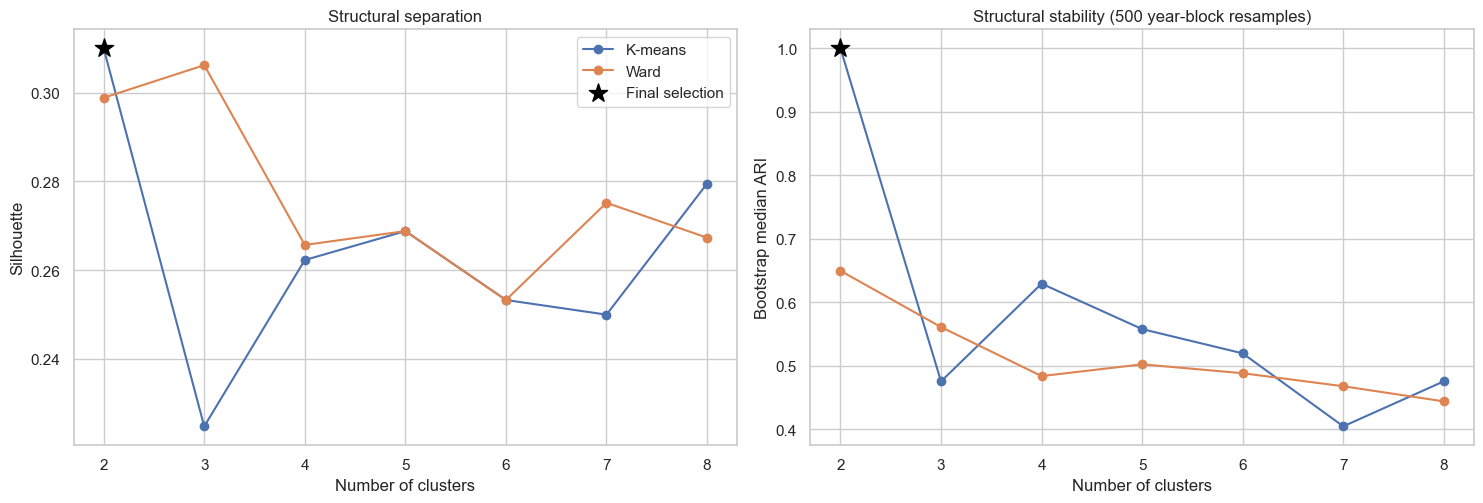

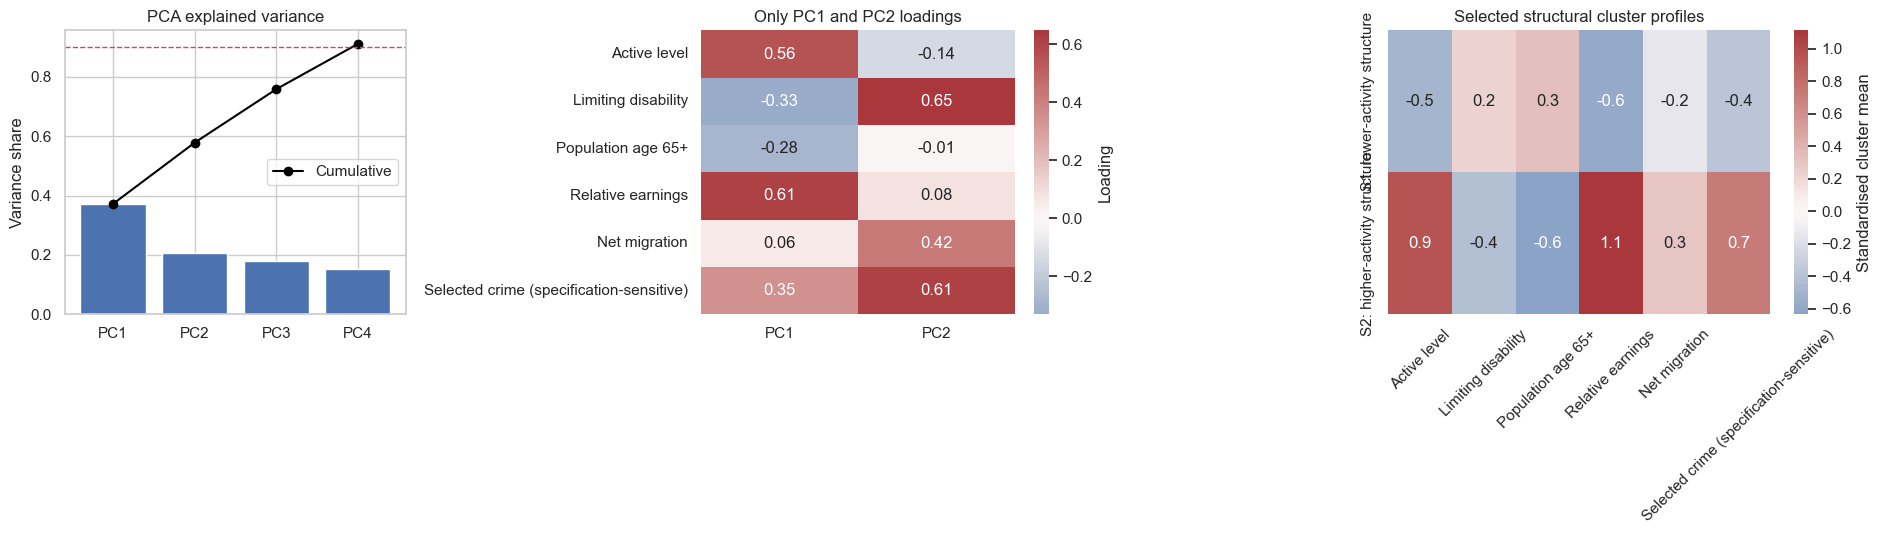

In [4]:
# Visualise candidate quality, the two interpretable PCA axes and selected cluster profiles.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for method, color in [('K-means', '#4C72B0'), ('Ward', '#DD8452')]:
    local = structural_candidates.loc[structural_candidates['method'].eq(method)]
    axes[0].plot(local['clusters'], local['silhouette'], marker='o', color=color, label=method)
axes[0].scatter(structural_winner['clusters'], structural_winner['silhouette'], marker='*',
                s=190, color='black', zorder=5, label='Final selection')
axes[0].set(title='Structural separation', xlabel='Number of clusters', ylabel='Silhouette')
axes[0].legend(title='')

# Repeat the same calculation across the required groups or settings.
for method, color in [('K-means', '#4C72B0'), ('Ward', '#DD8452')]:
    local = structural_candidates.loc[structural_candidates['method'].eq(method)]
    axes[1].plot(local['clusters'], local['bootstrap_median_ari'], marker='o', color=color, label=method)
axes[1].scatter(structural_winner['clusters'], structural_winner['bootstrap_median_ari'], marker='*',
                s=190, color='black', zorder=5)
axes[1].set(title=f'Structural stability ({CANDIDATE_BOOTSTRAPS} year-block resamples)',
            xlabel='Number of clusters', ylabel='Bootstrap median ARI')
# Create or format the figure for this comparison.
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), gridspec_kw={'width_ratios': [1, 1.15, 1.4]})
axes[0].bar(pca_explained['component'], pca_explained['explained_variance'], color='#4C72B0')
axes[0].plot(pca_explained['component'], pca_explained['cumulative_variance'],
             color='black', marker='o', label='Cumulative')
# Create or format the figure for this comparison.
axes[0].axhline(.90, color='#C44E52', linestyle='--', linewidth=1)
axes[0].set(title='PCA explained variance', xlabel='', ylabel='Variance share')
axes[0].legend(title='')

sns.heatmap(pca_loadings, cmap='vlag', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'Loading'}, ax=axes[1])
axes[1].set(title='Only PC1 and PC2 loadings', xlabel='', ylabel='')

# Calculate and store cluster heat for the following analysis step.
cluster_heat = structural_profile.groupby('structural_label')[STRUCTURAL_FEATURES].mean()
cluster_heat = (cluster_heat - structural_profile[STRUCTURAL_FEATURES].mean()) / structural_profile[
    STRUCTURAL_FEATURES
].std(ddof=0)
cluster_heat.columns = [FEATURE_LABELS[column] for column in cluster_heat.columns]
sns.heatmap(cluster_heat, cmap='vlag', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Standardised cluster mean'}, ax=axes[2])
# Create or format the figure for this comparison.
axes[2].set(title='Selected structural cluster profiles', xlabel='', ylabel='')
axes[2].tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

## 4. Structural specification sensitivity

The main typology includes Active level, so part of its separation may simply restate the outcome being studied. Selected crime is also explicitly treated as specification-sensitive. Two deletion checks therefore ask whether the borough partition survives without either variable.

The selected clustering method and number of clusters are held fixed. Each alternative is re-standardised and its PCA is refitted before clustering, so the comparison isolates the feature specification rather than reopening model selection. Silhouette measures separation, bootstrap median ARI measures stability across the same 500 year-block resamples, and ARI versus the main partition measures agreement with the published labels. The final column counts boroughs whose membership changes after labels are optimally aligned.


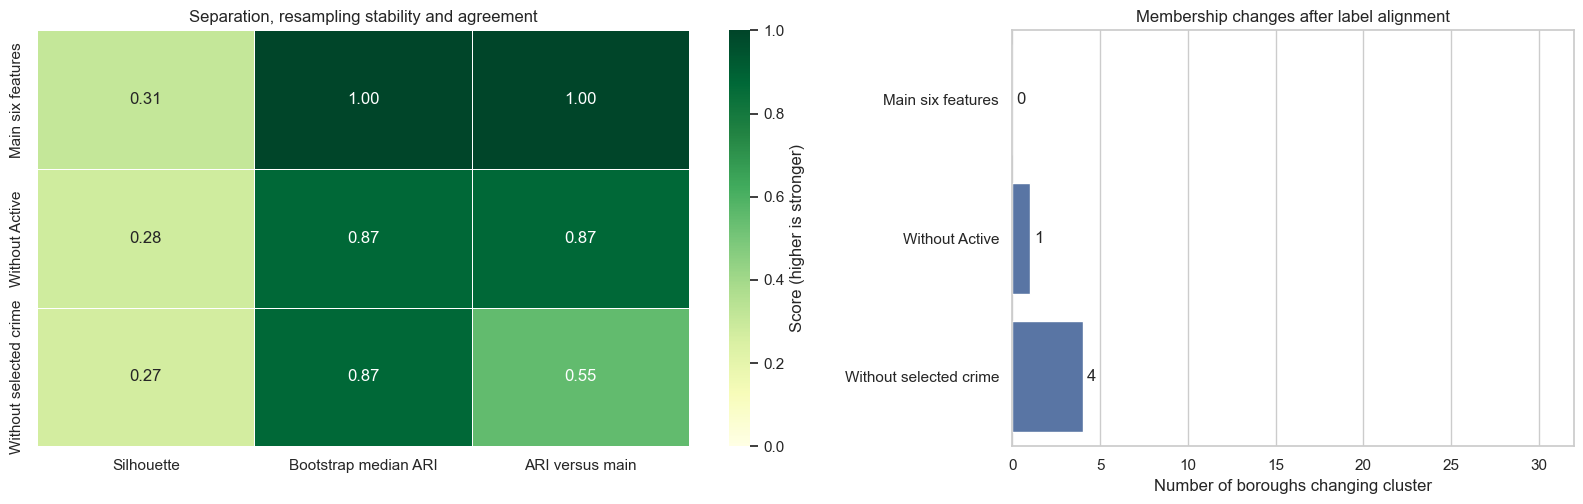

,Specification,Silhouette,Bootstrap median ARI,ARI versus main,Changed boroughs,Changed borough names
0,Main six features,0.310,1.000,1.000,0,
1,Without Active,0.280,0.874,0.874,1,Richmond upon Thames
2,Without selected crime,0.269,0.875,0.549,4,"Bromley, Kingston upon Thames, Lewisham, Merton"


In [5]:
# Test whether Active level or selected crime is essential to the structural partition.
STRUCTURAL_SENSITIVITY_SETS = {
    'Main six features': STRUCTURAL_FEATURES,
    'Without Active': [feature for feature in STRUCTURAL_FEATURES if feature != 'active_level'],
    'Without selected crime': [feature for feature in STRUCTURAL_FEATURES if feature != 'selected_crime'],
}


def align_partition(reference, candidate):
    """Align cluster numbers before counting boroughs that change membership."""
    reference_values = np.unique(reference)
    candidate_values = np.unique(candidate)
    contingency = np.array([
        [np.sum((reference == ref) & (candidate == cand)) for cand in candidate_values]
        for ref in reference_values
    ])
    rows, columns = linear_sum_assignment(-contingency)
    mapping = {candidate_values[column]: reference_values[row] for row, column in zip(rows, columns)}
    return np.array([mapping[value] for value in candidate])


def evaluate_structural_specification(name, features):
    """Refit one fixed-method, fixed-k feature specification and compare it with the main labels."""
    values = PCA(n_components=.90, random_state=RANDOM_STATE).fit_transform(
        StandardScaler().fit_transform(structural_profile[features])
    )
    labels = fit_cluster_labels(selected_method, selected_k, values)

    # Refit the same specification in every existing year-block resample.
    bootstrap_ari = []
    for repeat, sampled_profile in enumerate(structural_boot_profiles):
        sampled_values = PCA(
            n_components=.90, random_state=RANDOM_STATE + repeat
        ).fit_transform(StandardScaler().fit_transform(sampled_profile[features]))
        sampled_labels = fit_cluster_labels(
            selected_method, selected_k, sampled_values, RANDOM_STATE + repeat, n_init=5
        )
        bootstrap_ari.append(adjusted_rand_score(labels, sampled_labels))

    # Align arbitrary cluster numbers before identifying changed boroughs.
    aligned = align_partition(structural_raw_labels, labels)
    changed = aligned != structural_raw_labels
    return {
        'Specification': name,
        'Silhouette': silhouette_score(values, labels),
        'Bootstrap median ARI': np.median(bootstrap_ari),
        'ARI versus main': adjusted_rand_score(structural_raw_labels, labels),
        'Changed boroughs': int(changed.sum()),
        'Changed borough names': ', '.join(structural_profile.loc[changed, 'geography_name']),
    }


# Compare all three specifications using identical evaluation rules.
structural_sensitivity = pd.DataFrame([
    evaluate_structural_specification(name, features)
    for name, features in STRUCTURAL_SENSITIVITY_SETS.items()
])

# Keep the comparison compact: three agreement metrics and one direct change count.
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1.45, 1]})
metric_matrix = structural_sensitivity.set_index('Specification')[[
    'Silhouette', 'Bootstrap median ARI', 'ARI versus main'
]]
sns.heatmap(
    metric_matrix, cmap='YlGn', vmin=0, vmax=1, annot=True, fmt='.2f',
    linewidths=.6, cbar_kws={'label': 'Score (higher is stronger)'}, ax=axes[0],
)
axes[0].set(title='Separation, resampling stability and agreement', xlabel='', ylabel='')

sns.barplot(
    data=structural_sensitivity, x='Changed boroughs', y='Specification',
    color='#4C72B0', ax=axes[1],
)
axes[1].set(
    title='Membership changes after label alignment',
    xlabel='Number of boroughs changing cluster', ylabel='', xlim=(0, 32),
)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)
fig.tight_layout()
plt.show()

# Show borough names only where a deletion changes membership.
display(structural_sensitivity[[
    'Specification', 'Silhouette', 'Bootstrap median ARI',
    'ARI versus main', 'Changed boroughs', 'Changed borough names',
]].round(3))


### Interpretation

Removing Active lowers Silhouette from 0.310 to 0.280 and bootstrap median ARI from 1.000 to 0.874, but agreement with the main partition remains high (ARI 0.874) and only Richmond upon Thames changes cluster. The typology therefore is not simply a repackaged Active ranking.

Removing selected crime produces a more consequential change. The alternative remains reasonably stable across resamples (median ARI 0.875), yet its agreement with the main partition falls to 0.549 and Bromley, Kingston upon Thames, Lewisham and Merton change cluster. Selected crime is therefore not driving the entire two-group structure, but it materially affects four boundary cases. The main labels should retain the specification-sensitive qualification rather than being treated as definitive for those boroughs.


## 5. Structural membership and uncertainty

Hard labels hide borderline boroughs. For the selected solution, 1,000 year-block resamples are aligned back to the original labels. A borough's membership probability is the proportion of resamples assigning it to its displayed cluster; normalised entropy measures how dispersed its assignments are across all possible clusters.

The map therefore shows both the typology and confidence. The membership table is ordered by confidence so that uncertain boroughs are visible rather than silently treated as definite members.

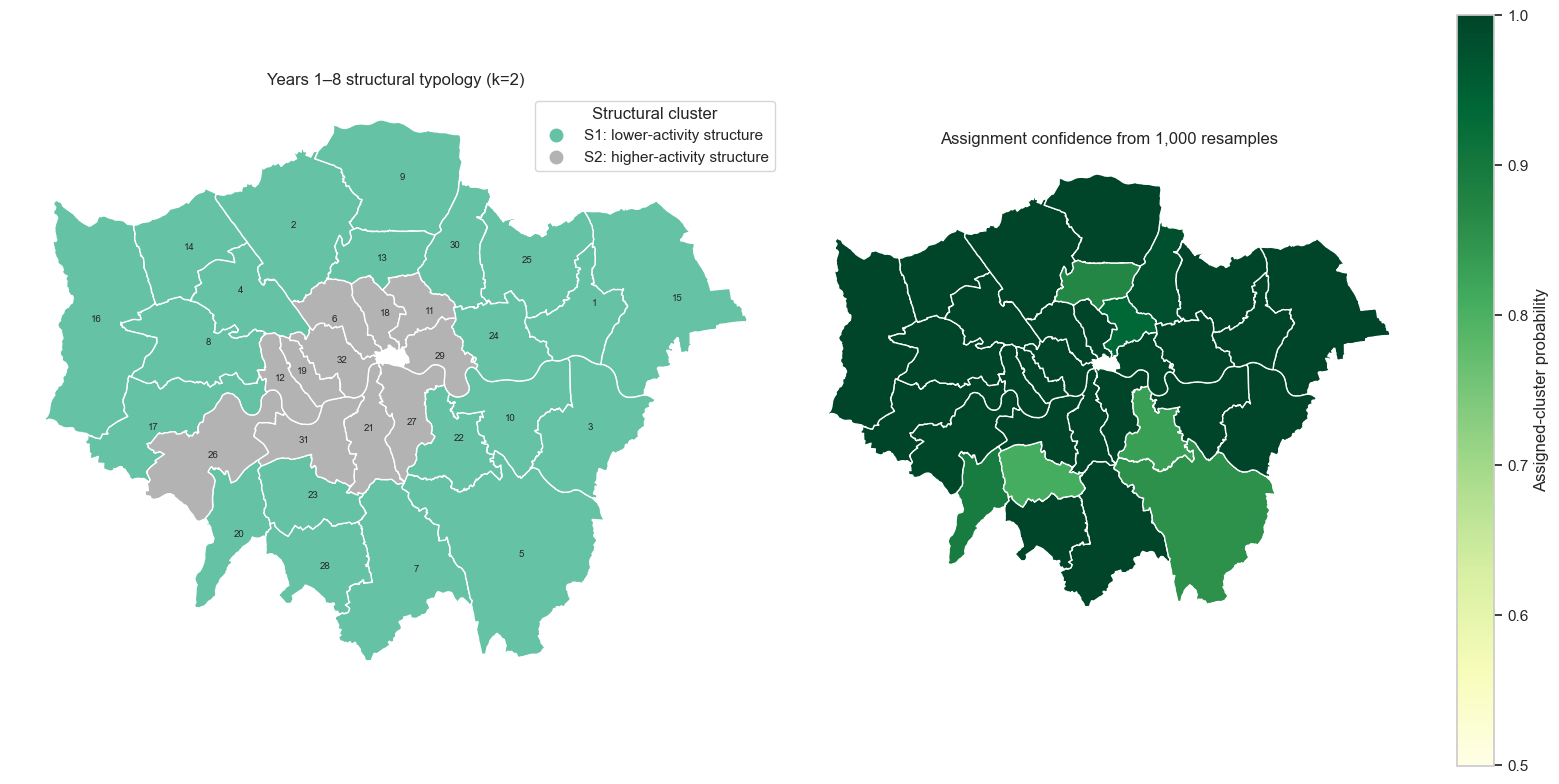

,map_id,geography_name,inner_outer,structural_label,structural_confidence,structural_entropy
22,23,Merton,Outer London,S1: lower-activity structure,0.808,0.706
21,22,Lewisham,Inner London,S1: lower-activity structure,0.831,0.655
4,5,Bromley,Outer London,S1: lower-activity structure,0.854,0.600
12,13,Haringey,Inner London,S1: lower-activity structure,0.873,0.549
19,20,Kingston upon Thames,Outer London,S1: lower-activity structure,0.894,0.488
10,11,Hackney,Inner London,S2: higher-activity structure,0.937,0.339
29,30,Waltham Forest,Outer London,S1: lower-activity structure,0.981,0.136
28,29,Tower Hamlets,Inner London,S2: higher-activity structure,0.995,0.045
25,26,Richmond upon Thames,Outer London,S2: higher-activity structure,0.995,0.045
23,24,Newham,Inner London,S1: lower-activity structure,0.999,0.011


In [6]:
# Align resampled labels and estimate a membership distribution for every borough.
def align_cluster_labels(reference, candidate):
    """Relabel a candidate partition to maximise agreement with a reference partition."""
    reference = np.asarray(reference)
    candidate = np.asarray(candidate)
    reference_values = np.unique(reference)
    candidate_values = np.unique(candidate)
    contingency = np.array([
        [np.sum((reference == ref) & (candidate == cand)) for cand in candidate_values]
        for ref in reference_values
    ])
    # Select the variables needed for this part of the analysis.
    rows, columns = linear_sum_assignment(-contingency)
    mapping = {candidate_values[column]: reference_values[row] for row, column in zip(rows, columns)}
    return np.array([mapping.get(value, value) for value in candidate])


# Define membership summary once so the same rule is reused consistently.
def membership_summary(reference, resampled_labels, prefix):
    """Convert aligned resampled assignments into probabilities, confidence and entropy."""
    reference = np.asarray(reference)
    classes = np.sort(np.unique(reference))
    aligned = np.vstack([align_cluster_labels(reference, labels) for labels in resampled_labels])
    probabilities = np.column_stack([(aligned == value).mean(axis=0) for value in classes])
    assigned_positions = np.array([np.where(classes == value)[0][0] for value in reference])
    confidence = probabilities[np.arange(len(reference)), assigned_positions]
    # Calculate and store safe for the following analysis step.
    safe = np.clip(probabilities, 1e-12, 1)
    entropy = -(safe * np.log(safe)).sum(axis=1) / np.log(len(classes)) if len(classes) > 1 else np.zeros(len(reference))
    result = pd.DataFrame({f'{prefix}_confidence': confidence, f'{prefix}_entropy': entropy})
    for position, value in enumerate(classes):
        result[f'{prefix}_p_cluster_{value}'] = probabilities[:, position]
    return result, aligned


# Calculate and store uncertainty rng for the following analysis step.
uncertainty_rng = np.random.default_rng(RANDOM_STATE + 10000)
structural_resampled_labels = []
for repeat in range(UNCERTAINTY_REPEATS):
    sampled_years = uncertainty_rng.choice(structural_years, size=len(structural_years), replace=True)
    sampled = pd.concat([
        structural_panel.loc[structural_panel['year'].eq(year)].assign(resample_position=position)
        for position, year in enumerate(sampled_years)
    ], ignore_index=True)
    sampled_profile = build_structural_profile(sampled).set_index('geography_code').reindex(
        structural_profile['geography_code']
    ).reset_index()
    # Calculate and store values for the following analysis step.
    values = PCA(n_components=.90, random_state=RANDOM_STATE + repeat).fit_transform(
        StandardScaler().fit_transform(sampled_profile[STRUCTURAL_FEATURES])
    )
    raw = fit_cluster_labels(selected_method, selected_k, values, RANDOM_STATE + repeat, n_init=5)
    ordered = pd.Series(raw).map({raw_value: rank for rank, raw_value in enumerate(
        sampled_profile.assign(raw_cluster=raw).groupby('raw_cluster')['active_level'].mean().sort_values().index,
        start=1,
    )}).to_numpy()
    # Apply the next transformation to the prepared analysis object.
    structural_resampled_labels.append(ordered)

# Calculate and store structural uncertainty, structural aligned boot for the following analysis step.
structural_uncertainty, structural_aligned_boot = membership_summary(
    structural_labels, structural_resampled_labels, 'structural'
)
structural_membership = pd.concat([
    structural_profile[['geography_code', 'geography_name', 'inner_outer',
                        'structural_cluster', 'structural_label']].reset_index(drop=True),
    structural_uncertainty,
], axis=1)
# Calculate and store structural membership['map id'] for the following analysis step.
structural_membership['map_id'] = np.arange(1, len(structural_membership) + 1)

cluster_map = borough_boundaries.merge(
    structural_membership, left_on='gss_code', right_on='geography_code', validate='one_to_one'
)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
cluster_map.plot(column='structural_label', categorical=True, cmap='Set2', edgecolor='white',
                 legend=True, legend_kwds={'title': 'Structural cluster'}, ax=axes[0])
# Repeat the same calculation across the required groups or settings.
for _, row in cluster_map.iterrows():
    point = row.geometry.representative_point()
    axes[0].text(point.x, point.y, int(row['map_id']), ha='center', va='center', fontsize=7)
axes[0].set_title(f'Years 1–8 structural typology (k={selected_k})')

cluster_map.plot(column='structural_confidence', cmap='YlGn', vmin=.5, vmax=1,
                 edgecolor='white', legend=True,
                 legend_kwds={'label': 'Assigned-cluster probability'}, ax=axes[1])
# Create or format the figure for this comparison.
axes[1].set_title(f'Assignment confidence from {UNCERTAINTY_REPEATS:,} resamples')
for axis in axes:
    axis.set_axis_off()
fig.tight_layout()
plt.show()

display(structural_membership.sort_values('structural_confidence')[[
    'map_id', 'geography_name', 'inner_outer', 'structural_label',
    'structural_confidence', 'structural_entropy',
]].round(3))

## 6. Annual trajectory design

The trajectory analysis uses all eight annual observations for every borough. Annual estimates are sufficiently precise for the purpose here and make the structural and trajectory analyses directly comparable.

Two representations answer different questions. **Level + trajectory** retains the original percentages, so persistent high/low activity, disruption and recovery all affect distance. **Shape-only** standardises each borough's own series to mean zero and standard deviation one, removing its usual level and asking only whether the curves have similar shapes.


In [7]:
# Prepare annual Active trajectories and compare candidate cluster solutions.
borough_order = structural_profile['geography_code'].tolist()
year_order = list(range(1, 9))
active_matrix = borough_annual.pivot(
    index='geography_code', columns='year', values='active_rate'
).reindex(index=borough_order, columns=year_order).to_numpy() * 100
effective_matrix = borough_annual.pivot(
    index='geography_code', columns='year', values='effective_n'
).reindex(index=borough_order, columns=year_order).to_numpy()
active_se_matrix = np.sqrt(
    (active_matrix / 100) * (1 - active_matrix / 100) / effective_matrix
) * 100


# Define standardise trajectory shape once so the same rule is reused consistently.
def standardise_trajectory_shape(values):
    "Remove each borough's own level and scale so only trajectory shape remains."
    values = np.asarray(values, float)
    row_means = values.mean(axis=1, keepdims=True)
    row_sd = values.std(axis=1, ddof=0, keepdims=True)
    return (values - row_means) / np.where(row_sd > 0, row_sd, 1)


# Calculate and store trajectory values for the following analysis step.
trajectory_values = {
    'Level + trajectory': active_matrix,
    'Shape-only trajectory': standardise_trajectory_shape(active_matrix),
}

# Perturb each estimate by its sampling uncertainty before checking label stability.
trajectory_rng = np.random.default_rng(RANDOM_STATE + 20000)
perturbed_active = [
    np.clip(trajectory_rng.normal(active_matrix, active_se_matrix), 0, 100)
    for _ in range(CANDIDATE_BOOTSTRAPS)
]
trajectory_boot_values = {
    'Level + trajectory': perturbed_active,
    'Shape-only trajectory': [standardise_trajectory_shape(values) for values in perturbed_active],
}

# Calculate and store trajectory candidate parts for the following analysis step.
trajectory_candidate_parts = []
for design, values in trajectory_values.items():
    rows = []
    for method in ['K-means', 'Ward']:
        for clusters in range(2, 9):
            base_labels = fit_cluster_labels(method, clusters, values)
            bootstrap_ari = [
                adjusted_rand_score(
                    base_labels,
                    fit_cluster_labels(method, clusters, boot_values,
                                       RANDOM_STATE + repeat, n_init=5),
                )
                for repeat, boot_values in enumerate(trajectory_boot_values[design])
            ]
            # Apply the next transformation to the prepared analysis object.
            rows.append({
                'design': design, 'method': method, 'clusters': clusters,
                'silhouette': silhouette_score(values, base_labels),
                'calinski_harabasz': calinski_harabasz_score(values, base_labels),
                'davies_bouldin': davies_bouldin_score(values, base_labels),
                'bootstrap_median_ari': np.median(bootstrap_ari),
                'bootstrap_p10_ari': np.quantile(bootstrap_ari, .10),
                'smallest_cluster': pd.Series(base_labels).value_counts().min(),
            })
    # Calculate and store ranked, winner for the following analysis step.
    ranked, winner = choose_candidate(pd.DataFrame(rows), MIN_CLUSTER_SIZE)
    trajectory_candidate_parts.append(ranked)

# Calculate and store trajectory candidates for the following analysis step.
trajectory_candidates = pd.concat(trajectory_candidate_parts, ignore_index=True)
trajectory_winners = trajectory_candidates.loc[trajectory_candidates['final_selection']].copy()
trajectory_shortlist = trajectory_candidates.loc[trajectory_candidates['eligible']].sort_values(
    ['design', 'final_selection', 'selection_score'], ascending=[True, False, False]
).groupby('design').head(3)

display(trajectory_shortlist[[
    'design', 'method', 'clusters', 'silhouette', 'bootstrap_median_ari',
    'smallest_cluster', 'final_selection',
]].round(3))


,design,method,clusters,silhouette,bootstrap_median_ari,smallest_cluster,final_selection
0,Level + trajectory,K-means,2,0.448,0.875,15,True
7,Level + trajectory,Ward,2,0.448,0.758,15,False
1,Level + trajectory,K-means,3,0.325,0.682,7,False
21,Shape-only trajectory,Ward,2,0.217,0.045,5,True
17,Shape-only trajectory,K-means,5,0.154,0.138,5,False
26,Shape-only trajectory,Ward,7,0.159,0.133,3,False


## 7. Final annual trajectory solutions

The annual **level + trajectory** solution is the main result because it gives the clearest separation and retains directly interpretable Active percentages. The shape-only result is kept as a sensitivity analysis because removing borough level leaves much weaker evidence of distinct curve types.

Thin lines below show individual boroughs and thick lines show cluster means. Assignment probabilities come from 1,000 perturbations using each borough-year estimate and its effective-sample-size standard error.


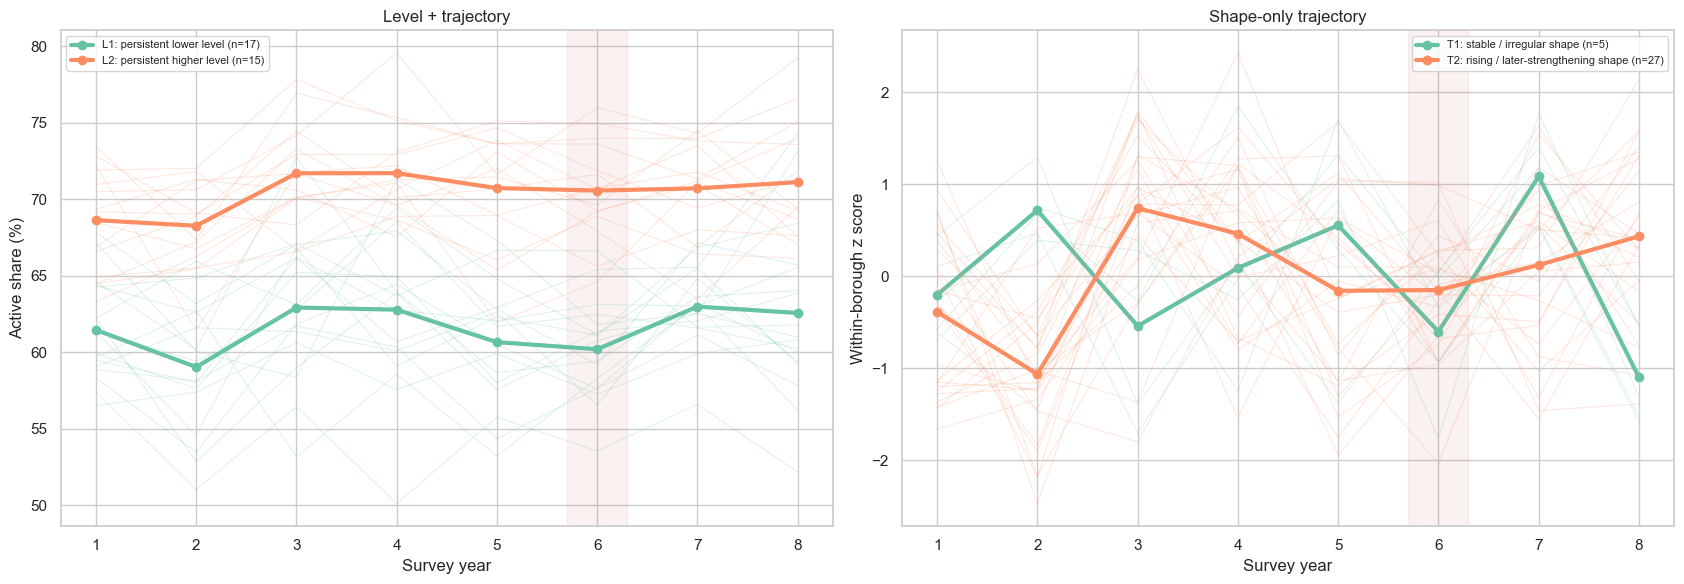

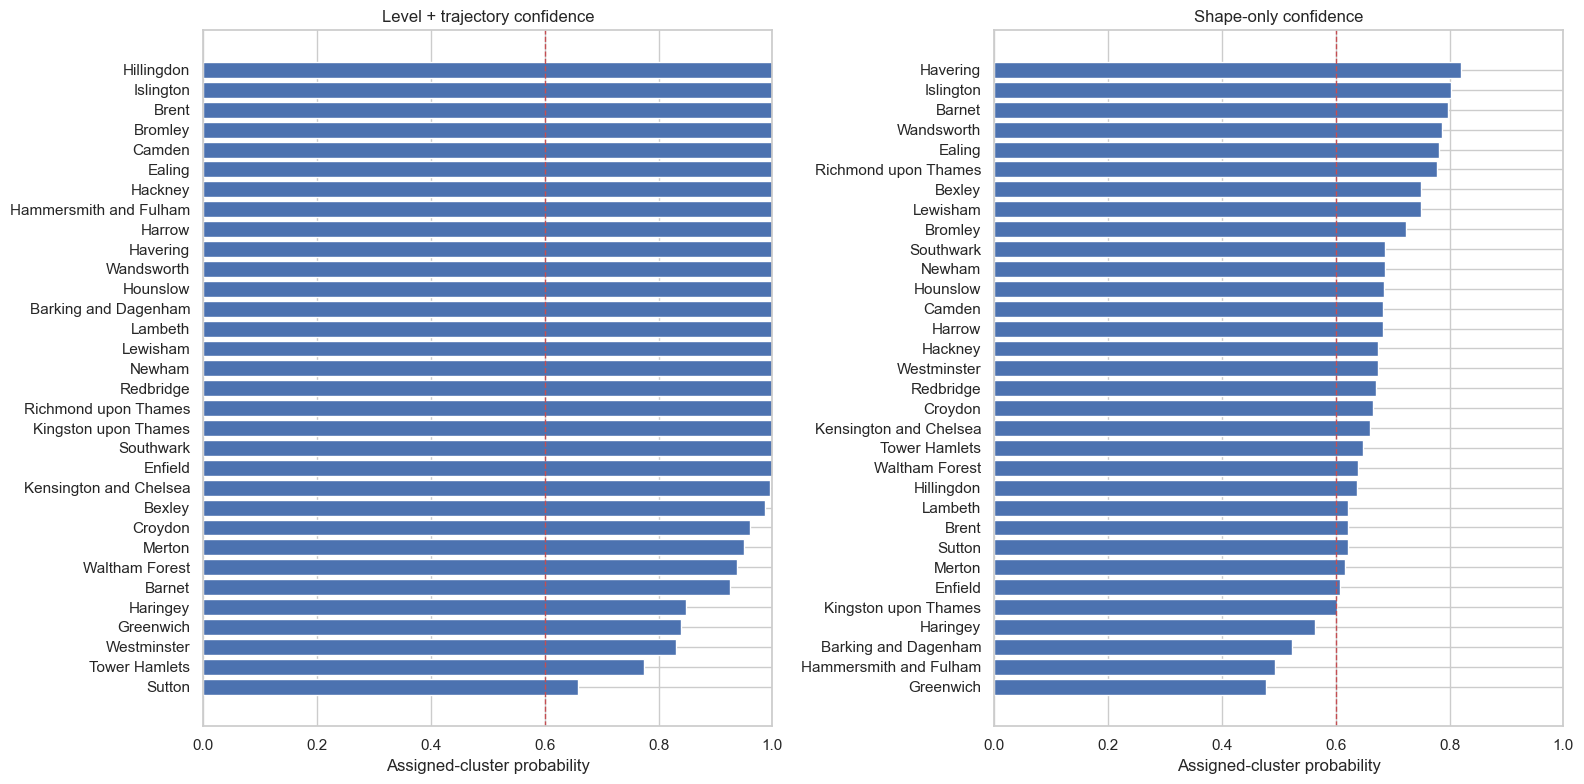

,design,cluster,label,boroughs,mean_active_pct,trend_pp,year6_dip_pp,year6_to_year8_recovery_pp
0,Level + trajectory,1,L1: persistent lower level,17,61.57,1.43,-1.17,2.37
1,Level + trajectory,2,L2: persistent higher level,15,70.42,2.11,0.36,0.55
2,Shape-only trajectory,1,T1: stable / irregular shape,5,64.66,-0.93,-1.76,-1.28
3,Shape-only trajectory,2,T2: rising / later-strengthening shape,27,65.92,2.25,-0.21,2.03


In [8]:
# Fit the selected trajectory solutions, label them transparently and estimate uncertainty.
trajectory_results = {}
trajectory_uncertainty_parts = []
trajectory_profile_rows = []

for design, values in trajectory_values.items():
    winner = trajectory_winners.loc[trajectory_winners['design'].eq(design)].iloc[0]
    method, clusters = winner['method'], int(winner['clusters'])
    raw_labels = fit_cluster_labels(method, clusters, values)

    if design == 'Level + trajectory':
        ordering_measure = pd.Series(raw_labels).map(
            pd.DataFrame({'label': raw_labels, 'level': active_matrix.mean(axis=1)})
            .groupby('label')['level'].mean().sort_values().rank(method='first').astype(int)
        ).to_numpy()
        ordered_labels = ordering_measure
        names = {
            rank: f'L{rank}: ' + ('persistent lower level' if rank == 1 else
                                  'persistent higher level' if rank == clusters else
                                  'middle level / distinct path')
            for rank in range(1, clusters + 1)
        }
    else:
        cluster_slopes = {
            raw: np.polyfit(year_order, values[raw_labels == raw].mean(axis=0), 1)[0]
            for raw in np.unique(raw_labels)
        }
        order = pd.Series(cluster_slopes).sort_values().index
        mapping = {raw: rank for rank, raw in enumerate(order, start=1)}
        ordered_labels = pd.Series(raw_labels).map(mapping).to_numpy()
        # Calculate and store shape descriptors for the following analysis step.
        shape_descriptors = {}
        for rank in range(1, clusters + 1):
            centroid = values[ordered_labels == rank].mean(axis=0)
            slope = np.polyfit(year_order, centroid, 1)[0]
            dip = centroid[5] - centroid[:5].mean()
            recovery = centroid[7] - centroid[5]
            if dip < -.5 and recovery > .5:
                descriptor = 'COVID dip + recovery shape'
            elif slope > .08:
                descriptor = 'rising / later-strengthening shape'
            elif slope < -.08:
                descriptor = 'declining / later-weakening shape'
            else:
                descriptor = 'stable / irregular shape'
            # Calculate and store shape descriptors[rank] for the following analysis step.
            shape_descriptors[rank] = descriptor
        # Calculate and store names for the following analysis step.
        names = {rank: f'T{rank}: {shape_descriptors[rank]}' for rank in range(1, clusters + 1)}

    # Calculate and store final rng for the following analysis step.
    final_rng = np.random.default_rng(RANDOM_STATE + 30000 + (0 if design.startswith('Level') else 1))
    resampled_labels = []
    for repeat in range(UNCERTAINTY_REPEATS):
        perturbed = np.clip(final_rng.normal(active_matrix, active_se_matrix), 0, 100)
        boot_values = perturbed if design.startswith('Level') else standardise_trajectory_shape(perturbed)
        boot_raw = fit_cluster_labels(method, clusters, boot_values, RANDOM_STATE + repeat, n_init=5)
        resampled_labels.append(boot_raw)

    # Calculate and store uncertainty, aligned for the following analysis step.
    uncertainty, aligned = membership_summary(ordered_labels, resampled_labels,
                                               'level' if design.startswith('Level') else 'shape')
    prefix = 'level' if design.startswith('Level') else 'shape'
    local = structural_profile[['geography_code', 'geography_name']].copy()
    local[f'{prefix}_cluster'] = ordered_labels
    local[f'{prefix}_label'] = pd.Series(ordered_labels).map(names)
    local = pd.concat([local.reset_index(drop=True), uncertainty], axis=1)
    # Apply the next transformation to the prepared analysis object.
    trajectory_uncertainty_parts.append(local)
    trajectory_results[design] = {
        'method': method, 'clusters': clusters, 'labels': ordered_labels,
        'names': names, 'values': values, 'membership': local,
    }

    for cluster in range(1, clusters + 1):
        raw_cluster_series = active_matrix[ordered_labels == cluster]
        mean_series = raw_cluster_series.mean(axis=0)
        trajectory_profile_rows.append({
            'design': design, 'cluster': cluster, 'label': names[cluster],
            'boroughs': int((ordered_labels == cluster).sum()),
            'mean_active_pct': mean_series.mean(),
            'trend_pp': np.polyfit(year_order, mean_series, 1)[0] * 7,
            'year6_dip_pp': mean_series[5] - mean_series[:5].mean(),
            'year6_to_year8_recovery_pp': mean_series[7] - mean_series[5],
        })

# Calculate and store level membership for the following analysis step.
level_membership = trajectory_results['Level + trajectory']['membership']
shape_membership = trajectory_results['Shape-only trajectory']['membership']
trajectory_profiles = pd.DataFrame(trajectory_profile_rows)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for axis, design in zip(axes, ['Level + trajectory', 'Shape-only trajectory']):
    result = trajectory_results[design]
    values = result['values']
    labels = result['labels']
    palette = sns.color_palette('Set2', result['clusters'])
    for cluster in range(1, result['clusters'] + 1):
        local_values = values[labels == cluster]
        for series in local_values:
            axis.plot(year_order, series, color=palette[cluster - 1], alpha=.20, linewidth=.8)
        axis.plot(year_order, local_values.mean(axis=0), color=palette[cluster - 1],
                  linewidth=3, marker='o', label=f"{result['names'][cluster]} (n={len(local_values)})")
    # Calculate and store axis.axvspan(5.7, 6.3, color for the following analysis step.
    axis.axvspan(5.7, 6.3, color='#C44E52', alpha=.08)
    axis.set(title=design, xlabel='Survey year',
             ylabel='Active share (%)' if design.startswith('Level') else 'Within-borough z score')
    axis.set_xticks(year_order)
    axis.legend(title='', fontsize=8)
# Create or format the figure for this comparison.
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for axis, membership, prefix, title in [
    (axes[0], level_membership, 'level', 'Level + trajectory confidence'),
    (axes[1], shape_membership, 'shape', 'Shape-only confidence'),
]:
    ordered = membership.sort_values(f'{prefix}_confidence')
    axis.barh(ordered['geography_name'], ordered[f'{prefix}_confidence'], color='#4C72B0')
    axis.axvline(.60, color='#C44E52', linestyle='--', linewidth=1)
    axis.set(title=title, xlabel='Assigned-cluster probability', ylabel='')
    axis.set_xlim(0, 1)
# Create or format the figure for this comparison.
fig.tight_layout()
plt.show()
display(trajectory_profiles.round(2))

## 8. Map the trajectory solutions and their uncertainty

The maps translate the trajectory groups back into geography. Each solution is shown twice: first as a cluster assignment and then as its assigned-cluster probability. The level map is the substantive trajectory result; the shape-only map is retained for transparency but must be read together with its much weaker stability.

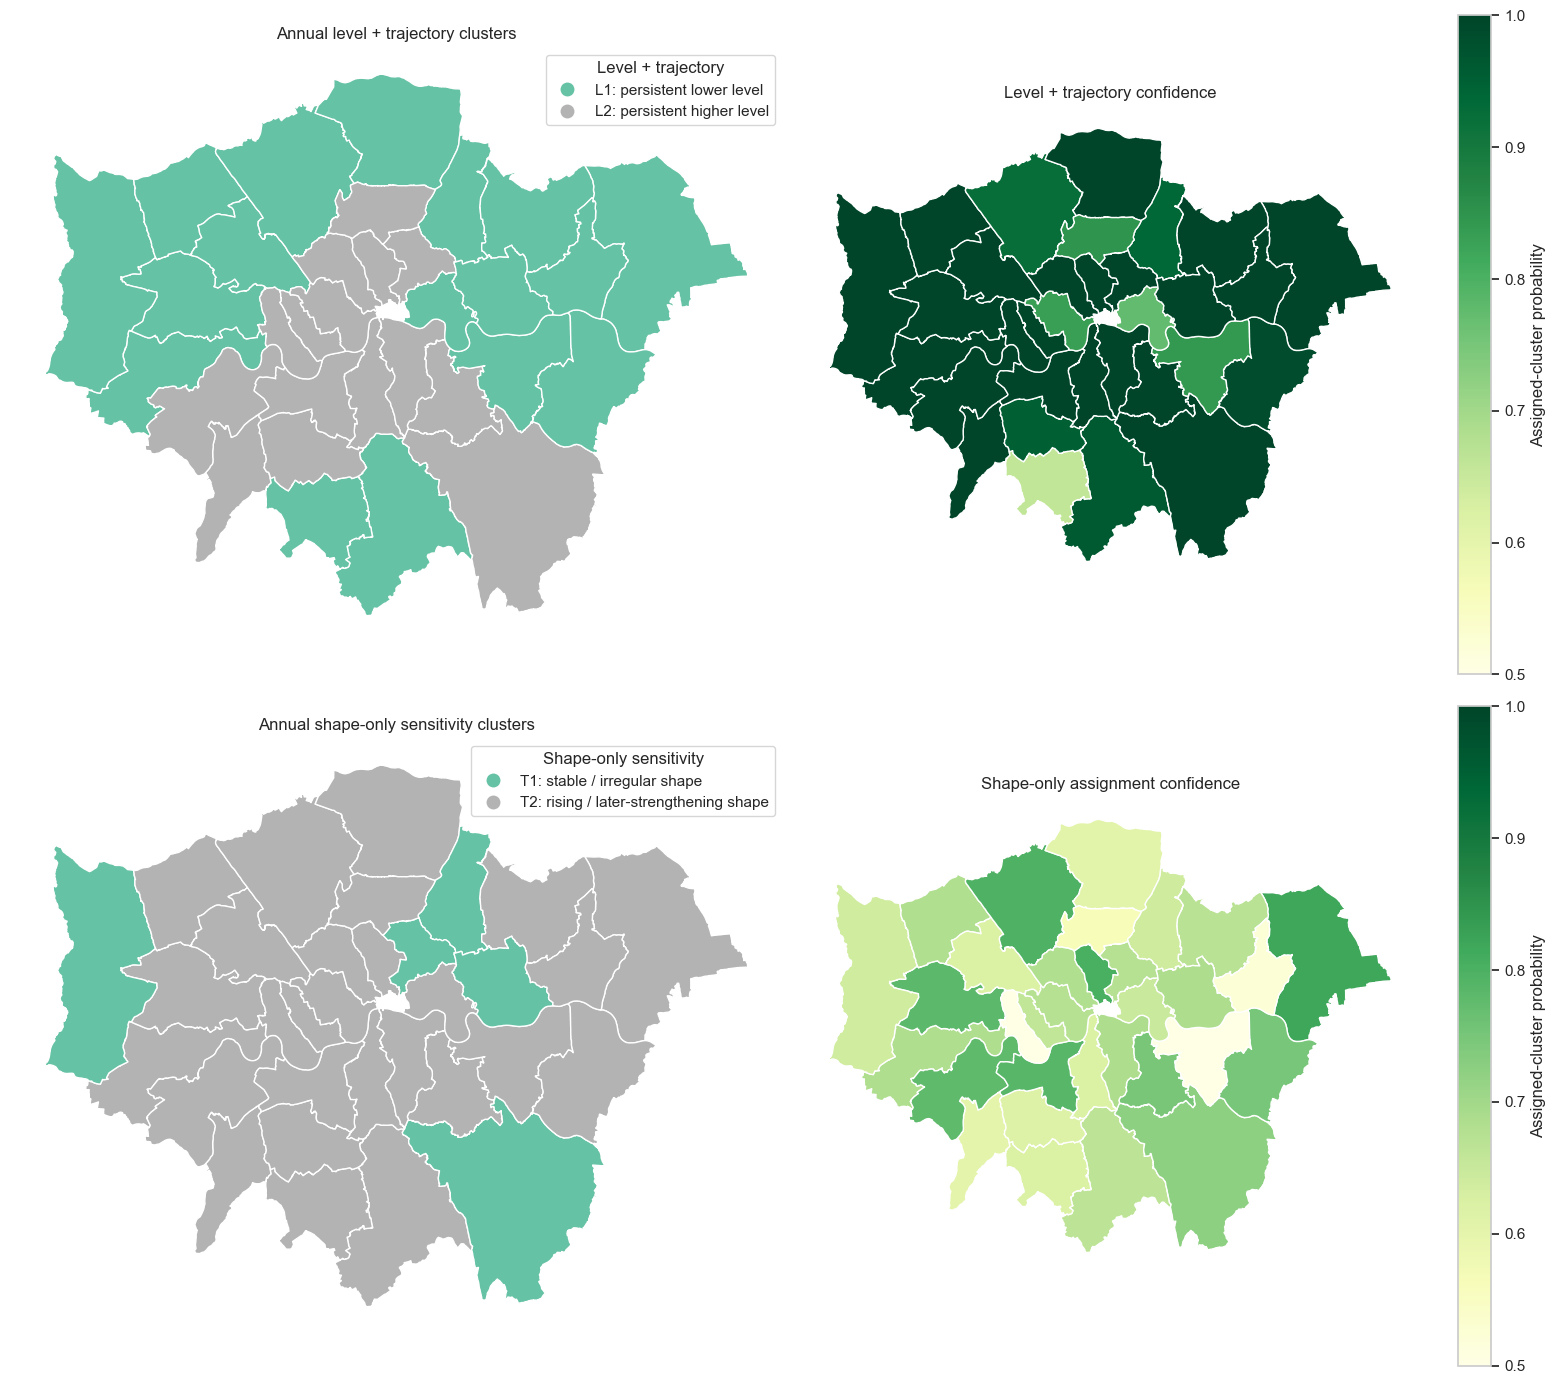

In [9]:
# Map both trajectory classifications and their borough-level confidence.
trajectory_map = borough_boundaries.merge(
    level_membership[['geography_code', 'level_label', 'level_confidence']],
    left_on='gss_code', right_on='geography_code', validate='one_to_one'
).merge(
    shape_membership[['geography_code', 'shape_label', 'shape_confidence']],
    on='geography_code', validate='one_to_one'
)

# Build the figure that presents the comparison clearly.
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
trajectory_map.plot(column='level_label', categorical=True, cmap='Set2', edgecolor='white',
                    legend=True, legend_kwds={'title': 'Level + trajectory'}, ax=axes[0, 0])
axes[0, 0].set_title('Annual level + trajectory clusters')
trajectory_map.plot(column='level_confidence', cmap='YlGn', vmin=.5, vmax=1,
                    edgecolor='white', legend=True,
                    legend_kwds={'label': 'Assigned-cluster probability'}, ax=axes[0, 1])
# Create or format the figure for this comparison.
axes[0, 1].set_title('Level + trajectory confidence')
trajectory_map.plot(column='shape_label', categorical=True, cmap='Set2', edgecolor='white',
                    legend=True, legend_kwds={'title': 'Shape-only sensitivity'}, ax=axes[1, 0])
axes[1, 0].set_title('Annual shape-only sensitivity clusters')
trajectory_map.plot(column='shape_confidence', cmap='YlGn', vmin=.5, vmax=1,
                    edgecolor='white', legend=True,
                    legend_kwds={'label': 'Assigned-cluster probability'}, ax=axes[1, 1])
# Create or format the figure for this comparison.
axes[1, 1].set_title('Shape-only assignment confidence')
for axis in axes.flat:
    axis.set_axis_off()
fig.tight_layout()
plt.show()


## 9. Structural clusters versus trajectory clusters

The final comparison does not assume that any classification is ground truth. Pairwise ARI asks whether two partitions group the same boroughs regardless of label numbering. Structural agreement with level + trajectory shows how much the contextual typology overlaps with persistent activity level; shape-only agreement shows whether curve form contributes a genuinely different pattern.

The membership table reports all labels with their probabilities. Low-probability boroughs should be described as borderline rather than forced into a definitive type.

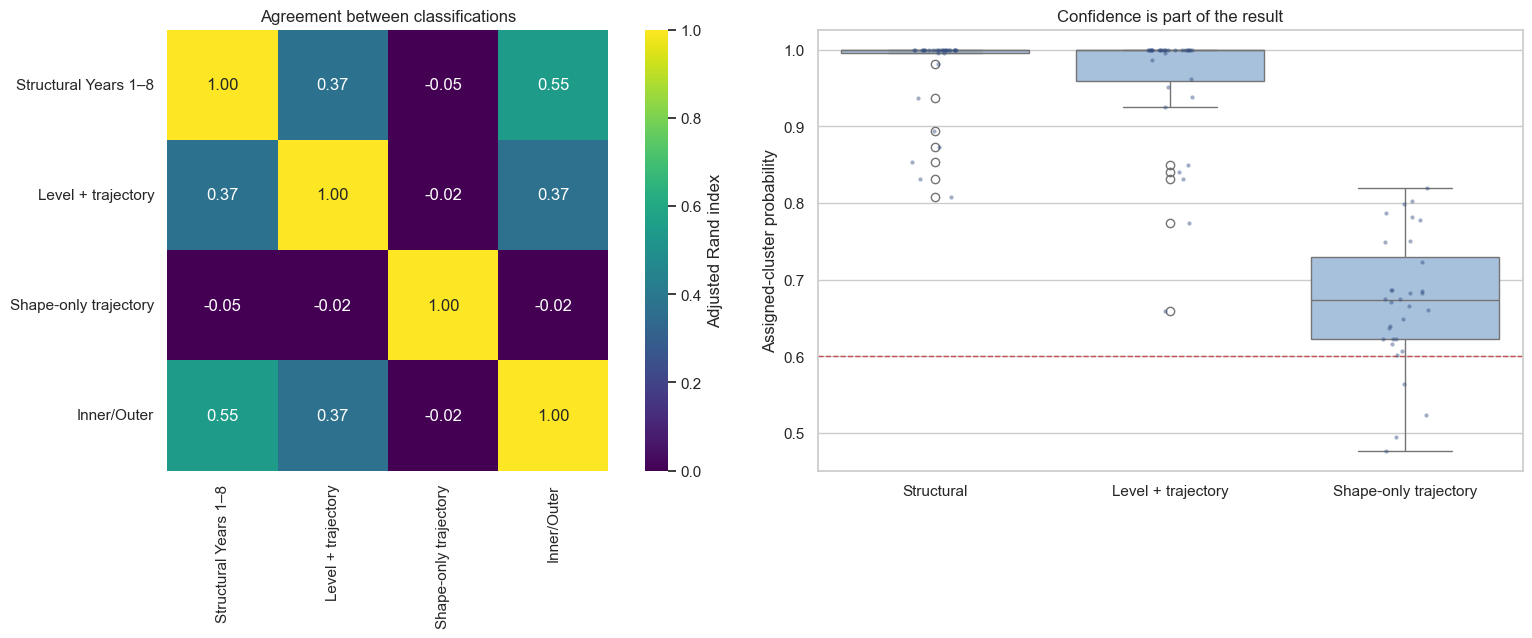

,geography_name,inner_outer,structural_label,structural_confidence,level_label,level_confidence,shape_label,shape_confidence
22,Merton,Outer London,S1: lower-activity structure,0.808,L2: persistent higher level,0.951,T2: rising / later-strengthening shape,0.616
21,Lewisham,Inner London,S1: lower-activity structure,0.831,L2: persistent higher level,1.000,T2: rising / later-strengthening shape,0.749
4,Bromley,Outer London,S1: lower-activity structure,0.854,L2: persistent higher level,1.000,T1: stable / irregular shape,0.723
12,Haringey,Inner London,S1: lower-activity structure,0.873,L2: persistent higher level,0.849,T2: rising / later-strengthening shape,0.564
19,Kingston upon Thames,Outer London,S1: lower-activity structure,0.894,L2: persistent higher level,1.000,T2: rising / later-strengthening shape,0.602
10,Hackney,Inner London,S2: higher-activity structure,0.937,L2: persistent higher level,1.000,T1: stable / irregular shape,0.675
29,Waltham Forest,Outer London,S1: lower-activity structure,0.981,L1: persistent lower level,0.938,T1: stable / irregular shape,0.639
28,Tower Hamlets,Inner London,S2: higher-activity structure,0.995,L1: persistent lower level,0.774,T2: rising / later-strengthening shape,0.648
25,Richmond upon Thames,Outer London,S2: higher-activity structure,0.995,L2: persistent higher level,1.000,T2: rising / later-strengthening shape,0.778
23,Newham,Inner London,S1: lower-activity structure,0.999,L1: persistent lower level,1.000,T1: stable / irregular shape,0.686


In [10]:
# Compare structural and trajectory partitions without treating one as truth.
comparison_membership = structural_membership[[
    'geography_code', 'geography_name', 'inner_outer', 'structural_label',
    'structural_cluster', 'structural_confidence',
]].merge(
    level_membership[['geography_code', 'level_label', 'level_cluster', 'level_confidence']],
    on='geography_code', validate='one_to_one'
).merge(
    shape_membership[['geography_code', 'shape_label', 'shape_cluster', 'shape_confidence']],
    on='geography_code', validate='one_to_one'
)

# Calculate and store partitions for the following analysis step.
partitions = {
    'Structural Years 1–8': comparison_membership['structural_cluster'],
    'Level + trajectory': comparison_membership['level_cluster'],
    'Shape-only trajectory': comparison_membership['shape_cluster'],
    'Inner/Outer': comparison_membership['inner_outer'].astype('category').cat.codes,
}
ari_matrix = pd.DataFrame(index=partitions, columns=partitions, dtype=float)
# Repeat the same calculation across the required groups or settings.
for row_name, row_labels in partitions.items():
    for column_name, column_labels in partitions.items():
        ari_matrix.loc[row_name, column_name] = adjusted_rand_score(row_labels, column_labels)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={'width_ratios': [1.05, 1]})
sns.heatmap(ari_matrix, cmap='viridis', vmin=0, vmax=1, annot=True, fmt='.2f', square=True,
            cbar_kws={'label': 'Adjusted Rand index'}, ax=axes[0])
# Create or format the figure for this comparison.
axes[0].set(title='Agreement between classifications', xlabel='', ylabel='')

confidence_long = comparison_membership.melt(
    id_vars=['geography_name'],
    value_vars=['structural_confidence', 'level_confidence', 'shape_confidence'],
    var_name='solution', value_name='assigned_probability',
)
# Calculate and store confidence labels for the following analysis step.
confidence_labels = {
    'structural_confidence': 'Structural', 'level_confidence': 'Level + trajectory',
    'shape_confidence': 'Shape-only trajectory',
}
confidence_long['solution'] = confidence_long['solution'].map(confidence_labels)
sns.boxplot(data=confidence_long, x='solution', y='assigned_probability',
            color='#9EC1E6', ax=axes[1])
# Add this result to the current visual comparison.
sns.stripplot(data=confidence_long, x='solution', y='assigned_probability',
              color='#2F4B7C', alpha=.45, size=3, ax=axes[1])
axes[1].axhline(.60, color='#C44E52', linestyle='--', linewidth=1)
axes[1].set(title='Confidence is part of the result', xlabel='',
            ylabel='Assigned-cluster probability')
fig.tight_layout()
plt.show()

# Display the finished visual or summary for interpretation.
display(comparison_membership.sort_values('structural_confidence')[[
    'geography_name', 'inner_outer', 'structural_label', 'structural_confidence',
    'level_label', 'level_confidence', 'shape_label', 'shape_confidence',
]].round(3))

# Final findings

## Structural borough typology using all eight years

The primary structural analysis uses **Years 1–8 together**. It selects **K-means with two clusters**: 21 boroughs in the lower-activity structure and 11 in the higher-activity structure. Silhouette is 0.310 and the median eight-year block-bootstrap ARI is 1.000. The smallest group contains 11 boroughs, so allowing a minimum of three rather than four has no effect on the final solution.

The six-feature design is retained because it is both conceptually balanced and empirically stronger. Adding participation frequency depth and log adult population reduces Silhouette from 0.310 to 0.243 and median ARI from 1.000 to 0.875. These additions are therefore excluded from the main model rather than kept merely to increase dimensionality.

The deletion checks clarify what the structural labels represent. Without Active, agreement with the main partition remains high (ARI 0.874) and only Richmond upon Thames changes cluster, so the typology is not merely an Active ranking. Without selected crime, agreement falls to 0.549 and four boroughs—Bromley, Kingston upon Thames, Lewisham and Merton—change membership despite good resampling stability. The broad two-group pattern survives, but the classification of these boundary boroughs is sensitive to the crime specification.

PCA retains four components and explains 91.1% of total variance. PC1 explains 37.2% and mainly contrasts higher Active levels and relative earnings with limiting disability and an older population. PC2 explains 20.6% and is driven mainly by limiting disability, selected crime and migration. Later components remain part of clustering distance but are not assigned speculative interpretations.

The structural solution is related to Inner/Outer London but is not identical to it (ARI 0.548). Borough-level confidence is generally high: the lowest assigned-cluster probabilities are Merton (0.808), Lewisham (0.831) and Bromley (0.854). These remain the most borderline structural cases.

## Annual level + trajectory solution

The formal trajectory result is the **annual level + trajectory K-means solution with two clusters**. Seventeen boroughs form a persistent lower-level group averaging 61.6% Active, while fifteen form a persistent higher-level group averaging 70.4%. Its Silhouette is 0.448 and median perturbation ARI is 0.875. Membership confidence is shown directly beside the cluster map.

The annual heatmap confirms that the separation is not produced by only the first and last observations. The higher-level group remains predominantly higher throughout the eight-year record, while the lower-level group contains more visible dips and uneven recovery. Both groups improve slightly overall. The lower-level group shows the clearer Year 6 dip (about −1.2 points relative to its earlier mean) followed by a 2.4-point recovery by Year 8; the higher-level group is more stable.

The level + trajectory solution agrees only moderately with the six-feature structural typology (ARI 0.372) and Inner/Outer London (ARI 0.371). Structural context and persistent activity level therefore overlap, but neither classification simply reproduces the other.

## Shape-only sensitivity

The annual shape-only analysis produces a small five-borough stable/irregular group and a 27-borough later-strengthening group. However, the selected Ward solution has Silhouette 0.217 and median perturbation ARI only 0.045. It also has essentially no agreement with the structural solution (ARI −0.05), level + trajectory solution (−0.02) or Inner/Outer London (−0.02).

The shape map is retained to show what the exploratory grouping looks like, but its confidence map and weak partition stability are part of the result. There is not enough evidence to present these shape labels as reliable borough types.

## Overall conclusion

The most defensible outputs are a stable two-group structural typology and a stable two-group annual level trajectory. The all-borough annual heatmap, cluster paths, maps and membership probabilities together show both the common pattern and the borough-level exceptions. Shape-only clustering remains useful as a sensitivity check, but not as a formal classification.
